In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(precision=4, suppress=True)

> ***personal note:***
>
> The `plot_function()` function visualizes a given function of a single variable over the interval $[a, b]$

In [2]:
import plotly.graph_objects as go

def _plot_function(f, bounds=(-16, 16), n=256):
  a, b = bounds
  xs = [a + i * (b - a) / n for i in range(n + 1)]
  ys = [f(x) for x in xs]
  fig = go.Figure(data=[go.Scatter(x=xs, y=ys, mode='lines')])
  fig.add_hline(y=0, line_color='black', line_width=1)
  fig.add_vline(x=0, line_color='black', line_width=1)
  # fig.show()
  fig.show(renderer="png")
  return fig

def _plot_surface(g, x_lab='x', y_lab='y', z_lab='z', ax_lo=-5, ax_hi=5, ay_lo=-5, ay_hi=5, n=60):
  xs = np.linspace(ax_lo, ax_hi, n + 1)
  ys = np.linspace(ay_lo, ay_hi, n + 1)
  Z = [[g(x, y) for x in xs] for y in ys]
  fig = go.Figure(data=[go.Surface(x=xs, y=ys, z=Z)])
  fig.update_layout(scene=dict(xaxis_title=x_lab, yaxis_title=y_lab, zaxis_title=z_lab), margin=dict(l=0, r=0, t=30, b=0),)
  # fig.show()
  fig.show(renderer="png")
  return fig

> _**personal note:**_
>
> a *Gaussian distribution* is a PDF of the form
>
> $$p(x) = \frac{1}{\sigma\sqrt{2\pi}}\, e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$
>
> where $\mu$ is the mean and $\sigma$ the standard deviation.

In [3]:
def _gaussian(mean, stdev):
  def gaussian(x):
    return (1 / (stdev * np.sqrt(2 * math.pi))) * np.exp(-0.5 * ((x - mean) / stdev) ** 2)
  return gaussian

> ***personal note:***
>
> we shall use OOP as the main paradigm of this project

In [4]:
class _ContinuousFunction:
  def __init__(self, f=None, bounds=None):
    self.f = (lambda x: x) if f is None else f
    self.bounds = (-128.0, 128.0) if bounds is None else bounds
  def __call__(self, *args):
    return self.f(*args)

In [ ]:
class _ContinuousRandomEvent():
  def __init__(self, f:_ContinuousFunction=None, p:_ContinuousFunction=None, bounds=None):
    self.f = _ContinuousFunction(f=lambda x: x) if f is None else f
    self.p = _ContinuousFunction(f=_gaussian(0.0, 1.0)) if p is None else p
    self.bounds = (
      tuple(map(max, self.f.bounds, self.p.bounds))) if bounds is None else bounds

In [6]:
def write_method(cls):
  def decorator(func):
    setattr(cls, func.__name__, func)
    return func
  return decorator

(-128.0, 128.0)


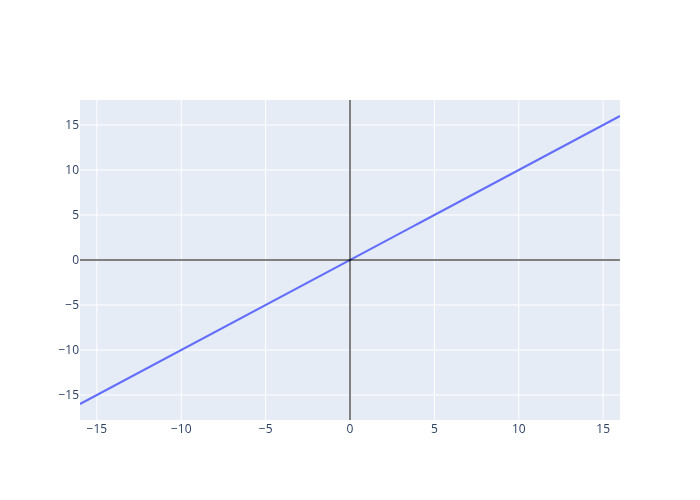

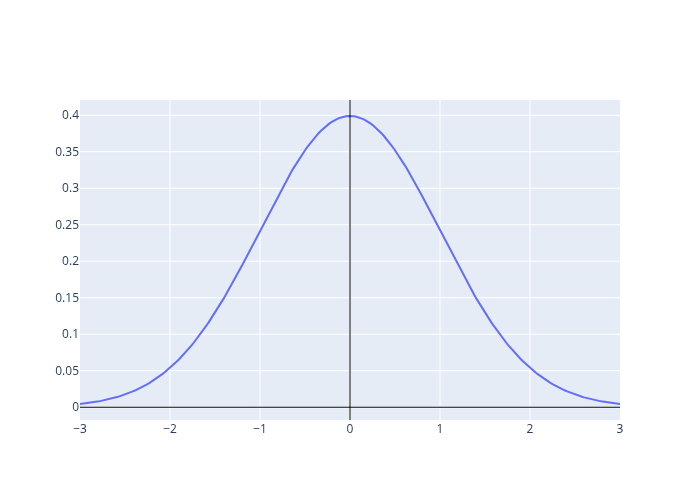

In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  x = _ContinuousRandomEvent()
  print(tuple(map(max, x.f.bounds, x.p.bounds)))
  _plot_function(x.f)
  _plot_function(x.p, (-3.0, 3.0))

> _**personal note:**_
>
> Numerical integration via **Simpson's rule** Approximates $\int_a^b f(x)\,dx$ by splitting $[a,b]$ into $n$ even panels and fitting a parabola through each consecutive triple of points.
>
> Each panel (3 points spaced by $h$) contributes:
>
> $$\int_{x_0}^{x_2} f(x)\,dx \approx \frac{h}{3}\left(f(x_0) + 4f(x_1) + f(x_2)\right)$$
>
> This method requires even $n$.

In [8]:
@write_method(_ContinuousFunction)
def _integrate_once(self, bounds=None, n_split=None):
  if n_split is None: n_split = 512 
  if bounds is None: bounds = self.bounds
  xs = np.linspace(*bounds, n_split + 1)
  w = np.ones(n_split + 1); w[1:-1:2] = 4; w[2:-1:2] = 2
  h = (bounds[1] - bounds[0]) / n_split
  return (h / 3) * np.sum(w * self.f(xs))

In [9]:
if __name__ == '__main__' and '__file__' not in globals():
  print(type(x.p._integrate_once()))
  print(f'{x.p._integrate_once():.4f}' )

<class 'numpy.float64'>
1.0000


> _**personal note:**_
>
> moving on `scipy.integrate.quad()` will be used as an optimized substitute of `__integrate()`.

In [10]:
import scipy

@write_method(_ContinuousFunction)
def _integrate_once(self, bounds=None, n_split=None):
  if bounds is None: bounds = self.bounds
  val, err = scipy.integrate.quad(self.f, *bounds)
  return np.float64(val)

In [11]:
if __name__ == '__main__' and '__file__' not in globals():
  print(type(x.p._integrate_once()))
  print(f'{x.p._integrate_once():.4f}' )

<class 'numpy.float64'>
1.0000


We say that a *random variable*, $x$, is distributed according to a particular PDF. Let $p(x)$ be a PDF for the random variable, $x$, over the interval $[a, b]$. This is a nonnegative function that satisfies

$$\int_a^b p(x)\,dx = 1. \tag{2.1}$$

That is, it satisfies the *axiom of total probability*. Note that this is *probability density*, not *probability*.

In [13]:
@write_method(_ContinuousFunction)
def is_pdf(self):
  if (abs(self._integrate_once() - 1) < 0.001):
    xs = np.arange(self.bounds[0], self.bounds[1] + 1, 0.125)
    if np.any(self.f(xs) < 0.0):
      return False
    return True
  return False

In [14]:
if __name__ == '__main__' and '__file__' not in globals():
  print(_ContinuousFunction(lambda x: x, (-2.0, 0.0)).is_pdf())
  print(_ContinuousFunction(lambda x: x, (0.0, 1.0)).is_pdf())
  print(_ContinuousFunction(lambda x: x, (0.0, math.sqrt(2))).is_pdf())
  print(_ContinuousFunction(_gaussian(0.0, 1.0)).is_pdf())

False
False
True
True


Probability is given by the area under the density function. For example, the probability that $x$ lies between $c$ and $d$, $\Pr(c \leq x \leq d)$, is given by

$$\Pr(c \leq x \leq d) = \int_c^d p(x)\,dx. \tag{2.2}$$

In [15]:
@write_method(_ContinuousFunction)
def probability(self, probability_bounds):
  return self._integrate_once(probability_bounds)

In [16]:
if __name__ == '__main__' and '__file__' not in globals():
  identity = lambda x: x
  print(_ContinuousFunction(lambda x: x).probability((0, 2)))
  print(_ContinuousFunction(lambda x: x).probability((0, 1)))
  print(_ContinuousFunction(lambda x: x).probability((0, 0)))

2.0
0.5
0.0


We will also make use of the *cumulative distribution function (CDF)* on occasion, which is given by

$$P(x) = \Pr(x' \leq x) = \int_{-\infty}^{x} p(x')\,dx', \tag{2.3}$$

In [17]:
@write_method(_ContinuousFunction)
def cumdist(self, x):
  return self.probability((self.bounds[0], x))

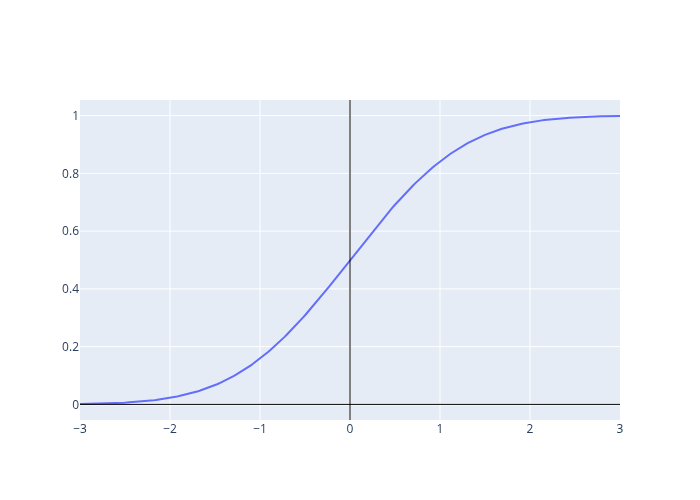

In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  x = _ContinuousRandomEvent(f=_ContinuousFunction(), 
                                p=_ContinuousFunction(_gaussian(0.0, 1.0)))
  _plot_function(x.p.cumdist, (-3.0, 3.0))

> _**personal note:**_
>
> the .sample() method of a function (given that its a pdf) gives a sample of a continuous function 

In [ ]:
@write_method(_ContinuousRandomEvent)
def sample(self, n):
  grid = np.linspace(*self.bounds, 2048)
  cumdist_vals = np.array([self.p.cumdist(x) for x in grid])
  inverse_cumdist = scipy.interpolate.interp1d(cumdist_vals, 
                                               grid, 
                                               bounds_error=False,
                                               fill_value=self.bounds)
  u = np.random.uniform(0, 1, n)
  return inverse_cumdist(u)

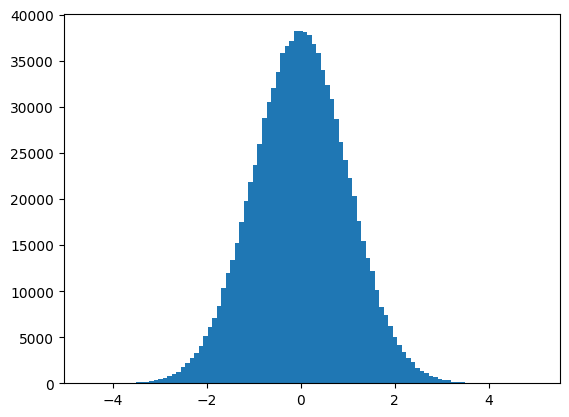

In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  x1 = _ContinuousRandomEvent(p=_ContinuousFunction(f=_gaussian(0.0, 1.0)))
  x1_sample = x1.sample(1000000)
  # print(x1_sample)
  plt.hist(x1_sample, bins=100)

We can also introduce a conditioning variable to PDFs. Let $p(x|y)$ be a PDF over $x \in [a, b]$ conditioned on $y \in [r, s]$ such that

$$(\forall y) \quad \int_a^b p(x|y)\,dx = 1. \tag{2.4}$$

We may also denote *joint probability densities* for $N$-dimensional continuous variables in our framework as $p(\mathbf{x})$, where $\mathbf{x} = (x_1, \dots, x_N)$ with $x_i \in [a_i, b_i]$. Note that we can also use the notation

$$p(x_1, x_2, \dots, x_N) \tag{2.5}$$

in place of $p(\mathbf{x})$.

Sometimes we even mix and match the two and write

$$p(\mathbf{x}, \mathbf{y}) \tag{2.6}$$

for the joint density of $\mathbf{x}$ and $\mathbf{y}$.

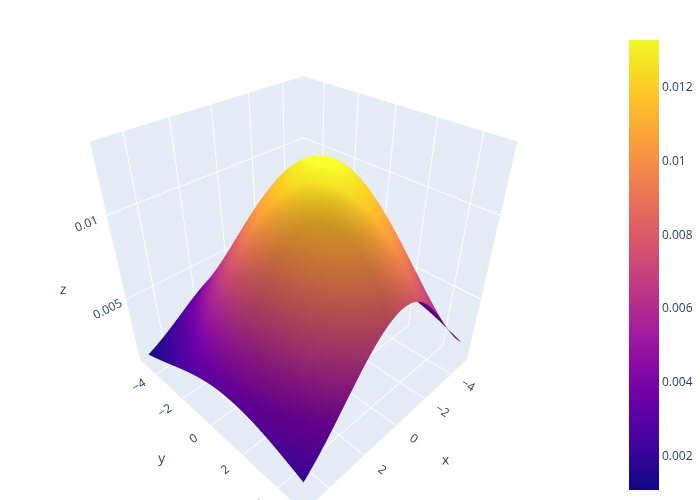

In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  FX = _ContinuousFunction(f=lambda x1, x2: (x1, x2))
  pX = _ContinuousFunction(f=lambda x1, x2:
                            _ContinuousFunction(_gaussian(0.0, 3.0))(x1) *
                            _ContinuousFunction(_gaussian(1.0, 4.0))(x2))
  X = _ContinuousRandomEvent(f=FX, p=pX)
  _plot_surface(X.p)

for the joint density of $\mathbf{x}$ and $\mathbf{y}$. In the $N$-dimensional case, the axiom of total probability requires

$$\int_{\mathbf{a}}^{\mathbf{b}} p(\mathbf{x})\,d\mathbf{x} = \int_{a_N}^{b_N} \cdots \int_{a_2}^{b_2} \int_{a_1}^{b_1} p(x_1, x_2, \dots, x_N)\,dx_1\,dx_2 \cdots dx_N = 1, \tag{2.7}$$

where $\mathbf{a} = (a_1, a_2, \dots, a_N)$ and $\mathbf{b} = (b_1, b_2, \dots, b_N)$. In what follows, we will sometimes simplify notation by leaving out the integration limits, $\mathbf{a}$ and $\mathbf{b}$.

In [23]:
import inspect

@write_method(_ContinuousFunction)
def _integrate_once(self, f=None, bounds=None, n_split=None):
  if f is None: f = self.f
  if bounds is None: bounds = self.bounds
  val, err = scipy.integrate.quad(f, *bounds)
  return np.float64(val)

# note: this is exponentially expensive (O(n^n)) but works as a proof of concept
@write_method(_ContinuousFunction)
def integrate(self, f=None, bounds=None):
  if f is None: f = self.f
  if bounds is None: bounds = self.bounds
  
  if len(bounds) == 1:
    return self._integrate_once(f=f, bounds=bounds[0])
  else:
    def inner(x):
      return self.integrate(f=(lambda *rest: f(x, *rest)), 
                             bounds=bounds[1:])
    return self._integrate_once(f=inner, bounds=bounds[0])


In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  x = _ContinuousRandomEvent(f=_ContinuousFunction(), 
                                p=_ContinuousFunction(_gaussian(0.0, 1.0), [(-128.0, 128.0)]),
                                bounds=[(-128.0, 128.0)])
  print(f'{x.p.integrate():.4f}')

1.0000


In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  FX = _ContinuousFunction(
    f=(lambda x1, x2: (x1, x2)),
    bounds=[(-128, 128), (-128, 128)])
  pX = _ContinuousFunction(
    f=(lambda x1, x2:
                _ContinuousFunction(_gaussian(0.0, 3.0))(x1) *
                _ContinuousFunction(_gaussian(1.0, 4.0))(x2)),
    bounds=[(-128, 128), (-128, 128)])
  X = _ContinuousRandomEvent(f=FX, p=pX)
  print(type(pX.integrate()))
  print(f'{pX.integrate():.4f}')

<class 'numpy.float64'>
1.0000


<center>

**Testing/Playground Below** 

<small><em>
(always wrap with `if __name__ == '__main__' and '__file__' not in globals():`)
</em></small>

</center>